<a href="https://colab.research.google.com/github/shantyzapata/IA-and-ML/blob/main/Parcial_1_Redneuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Red Nueronal***
<br>Santiago Zapata

***Preparación de Dataset***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("apple_quality.csv")

df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   object 
 8   Quality      4000 non-null   object 
dtypes: float64(7), object(2)
memory usage: 281.4+ KB


,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,1999.500000,-0.503015,-0.989547,-0.470479,0.985478,0.512118,0.498277
std,1154.844867,1.928059,1.602507,1.943441,1.402757,1.930286,1.874427
min,0.000000,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599
25%,999.750000,-1.816765,-2.011770,-1.738425,0.062764,-0.801286,-0.771677
50%,1999.500000,-0.513703,-0.984736,-0.504758,0.998249,0.534219,0.503445
75%,2999.250000,0.805526,0.030976,0.801922,1.894234,1.835976,1.766212
max,3999.000000,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837


In [ ]:
df.isnull().sum()

,0
A_id,1
Size,1
Weight,1
Sweetness,1
Crunchiness,1
Juiciness,1
Ripeness,1
Acidity,0
Quality,1


### 1. Convertir Quality a número

Realizamos la clasificación de la calidad de la manzana para comprender como afectan las variables en la calidad de la misma

In [ ]:
df["Quality"] = df["Quality"].map({"good":1,"bad":0})

### 2. Correlación

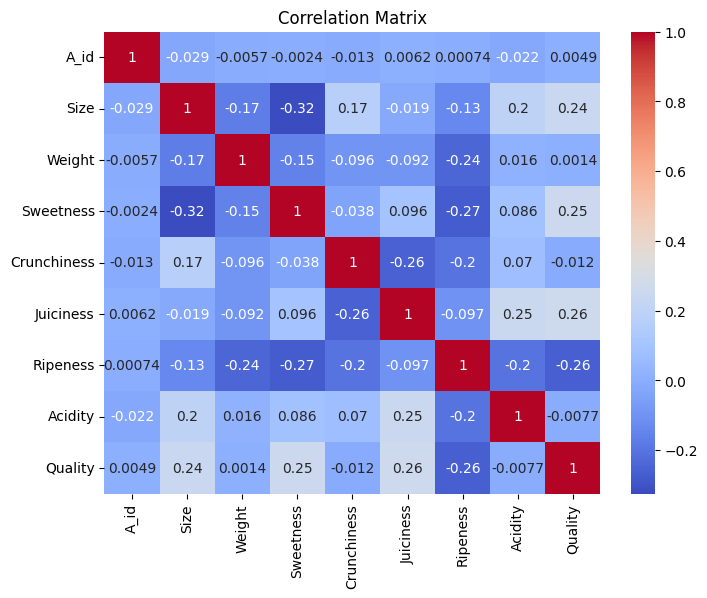

In [ ]:
df['Acidity'] = pd.to_numeric(df['Acidity'], errors='coerce')
df.dropna(inplace=True)
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### 3. Distribución de variables

Se realiza el analisis exploratorio (EDA) de cada una de las variables que interfieren en la calidad de la manzana

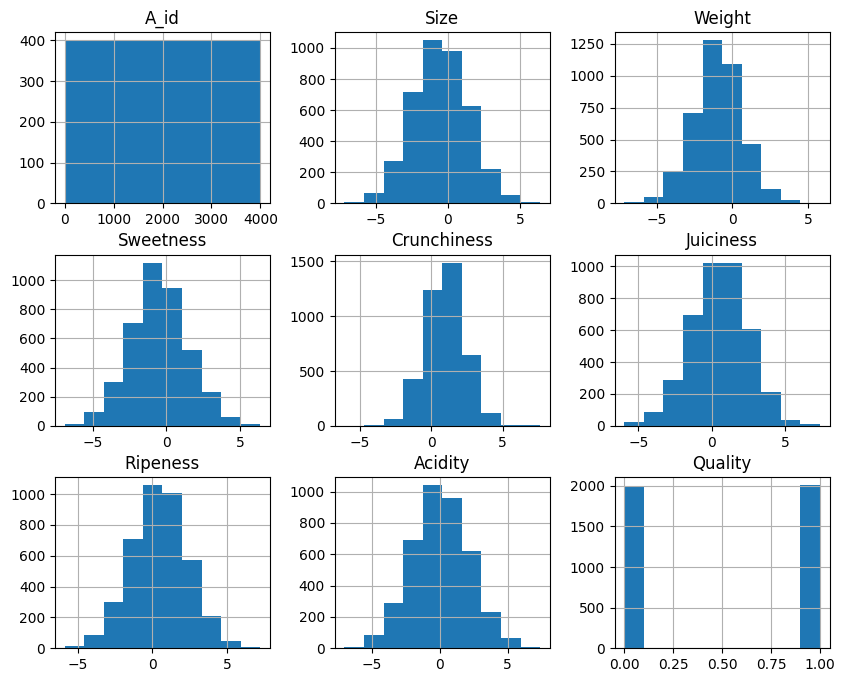

In [ ]:
df.hist(figsize=(10,8))
plt.show()

Se muestran 1x1 las variables para identificar como afectan la calidad entre 0 y 1, donde 0 es mala y 1 es buena

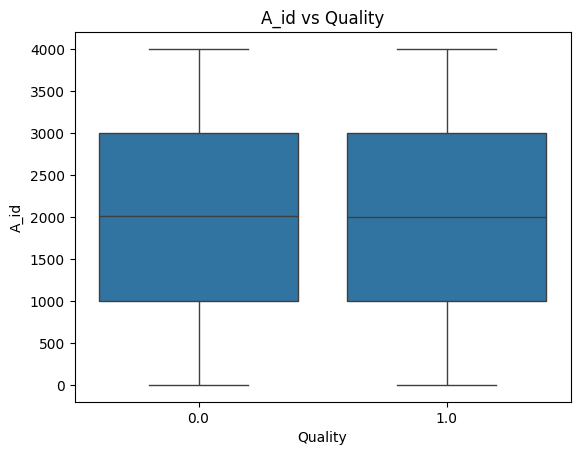

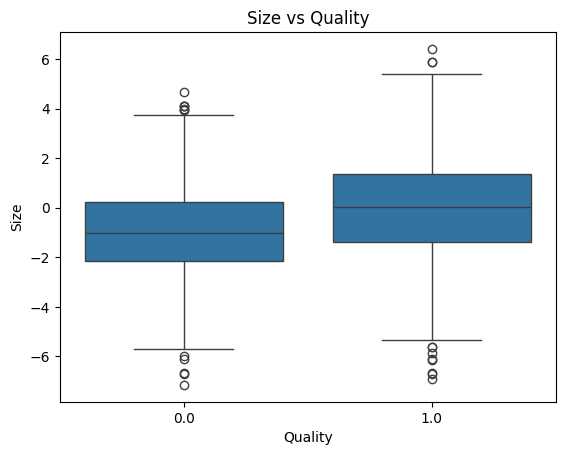

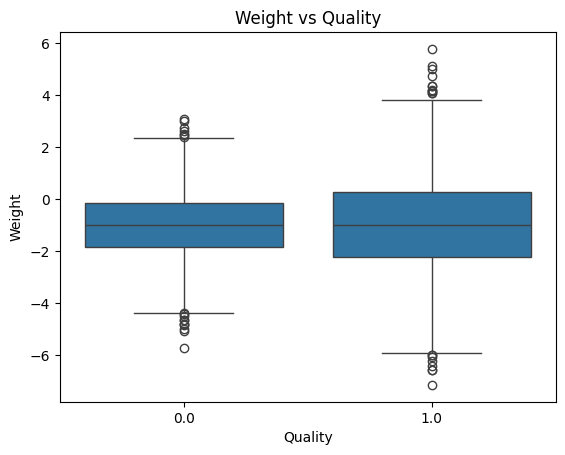

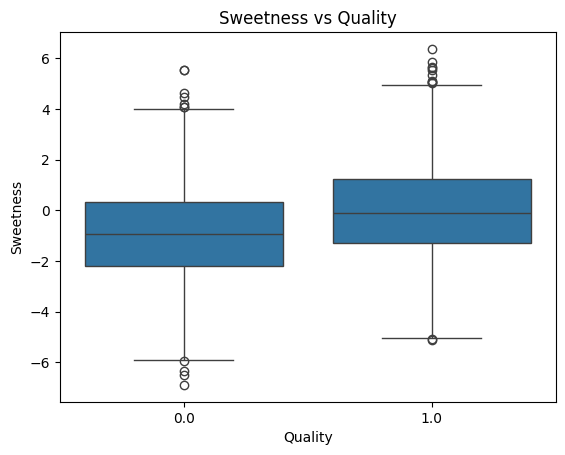

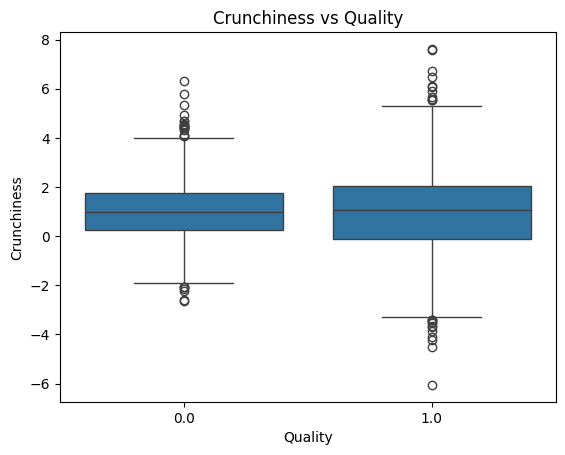

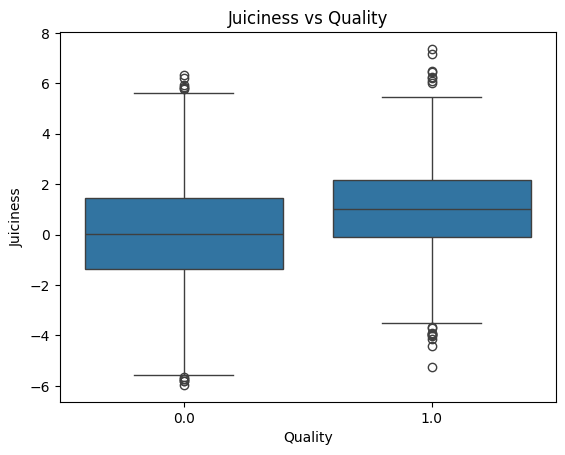

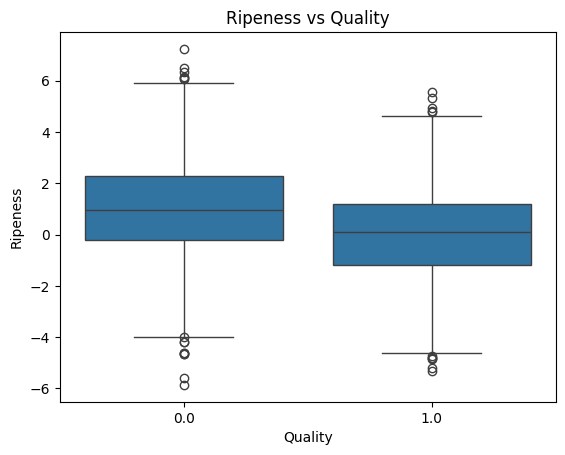

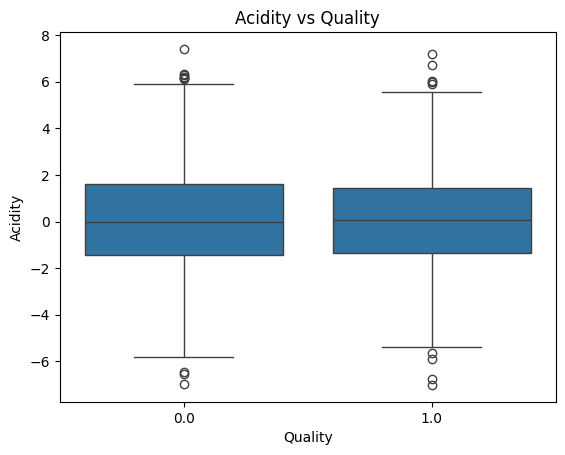

In [ ]:
features = df.columns[:-1]

for f in features:
    plt.figure()
    sns.boxplot(x="Quality", y=f, data=df)
    plt.title(f + " vs Quality")
    plt.show()

### Hipotesis

1. Las manzanas más dulces tienen mayor probabilidad de ser de buena calidad.

2. Las manzanas más jugosas tienden a clasificarse como buenas.

3. La acidez alta puede afectar negativamente la calidad.

### 4. Preparación y normalización de datos

In [ ]:
X = df.drop("Quality", axis=1).values
y = df["Quality"].values.reshape(-1,1)

In [ ]:
print(X.shape)
print(y.shape)

(4000, 8)
(4000, 1)


In [ ]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [ ]:
### Dividir 80/20

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### 5. Red Neuronal

Preparamos el diseño de la red nueronal para poder hacer los calculos posteriores del fordward propagation y backpropagation

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

### 6. Inicializar pesos

In [ ]:
np.random.seed(42)

input_size = 8
hidden1 = 5
hidden2 = 3
output_size = 1

W1 = np.random.randn(input_size, hidden1)
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2)
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, output_size)
b3 = np.zeros((1, output_size))

### 7. Fordward propagation

In [ ]:
def forward(X):

    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)

    z2 = np.dot(a1, W2) + b2
    a2 = relu(z2)

    z3 = np.dot(a2, W3) + b3
    a3 = sigmoid(z3)

    return z1,a1,z2,a2,z3,a3

### 8. Backpropagation

Se hace un entrenamiento por epocas y ratio de aprendizaje, en donde la convergencia se aprecia al completar 20 epocas, y el learn rate (lr) que puede variar, afecta la precisión para corregir el error

In [ ]:
def train(X, y, epochs=1000, lr=0.01):

    global W1,W2,W3,b1,b2,b3

    for i in range(epochs):

        z1,a1,z2,a2,z3,a3 = forward(X)

        error = a3 - y

        d3 = error * sigmoid_derivative(a3)

        d2 = np.dot(d3, W3.T) * relu_derivative(a2)

        d1 = np.dot(d2, W2.T) * relu_derivative(a1)

        W3 -= lr * np.dot(a2.T, d3)
        b3 -= lr * np.sum(d3, axis=0)

        W2 -= lr * np.dot(a1.T, d2)
        b2 -= lr * np.sum(d2, axis=0)

        W1 -= lr * np.dot(X.T, d1)
        b1 -= lr * np.sum(d1, axis=0)

        if i % 100 == 0:
            loss = np.mean(error**2)
            print("Epoch:",i/100,"Loss:",loss*100)

In [ ]:
train(X_train, y_train, epochs=2000, lr=0.01)

Epoch: 0.0 Loss: 32.52041135433523
Epoch: 1.0 Loss: 10.477254807100532
Epoch: 2.0 Loss: 9.58481239429841
Epoch: 3.0 Loss: 9.371965303681755
Epoch: 4.0 Loss: 9.220166929647183
Epoch: 5.0 Loss: 9.212492426988927
Epoch: 6.0 Loss: 9.23425833946662
Epoch: 7.0 Loss: 9.703910184176303
Epoch: 8.0 Loss: 9.207913419762122
Epoch: 9.0 Loss: 8.689027194246961
Epoch: 10.0 Loss: 8.840087620538792
Epoch: 11.0 Loss: 9.13578240401999
Epoch: 12.0 Loss: 8.491717467210048
Epoch: 13.0 Loss: 8.636576607503626
Epoch: 14.0 Loss: 8.537220018309442
Epoch: 15.0 Loss: 8.523197945377994
Epoch: 16.0 Loss: 8.928451941602146
Epoch: 17.0 Loss: 8.57686015284952
Epoch: 18.0 Loss: 8.946233831249746
Epoch: 19.0 Loss: 8.582879363155465


In [ ]:
_,_,_,_,_,pred = forward(X_test)

pred = (pred > 0.5).astype(int)

accuracy = np.mean(pred == y_test)

print("Accuracy:", accuracy)

Accuracy: 0.86375


In [ ]:
correct = np.sum(pred == y_test)
total = len(y_test)

print("Correctos:", correct)
print("Total:", total)

Correctos: 691
Total: 800


In [ ]:
resultados = pd.DataFrame({
    "Real": y_test.flatten(),
    "Predicho": pred.flatten()
})

print(resultados.head(10))

   Real  Predicho
0   1.0         1
1   0.0         0
2   0.0         1
3   1.0         1
4   0.0         0
5   0.0         1
6   0.0         0
7   0.0         0
8   1.0         1
9   1.0         0


### 9. Gráfica de la arquitectura

Se grafíca el modelo de la red neuronal de 2 capas ocultas, 1 entrada y 1 salida

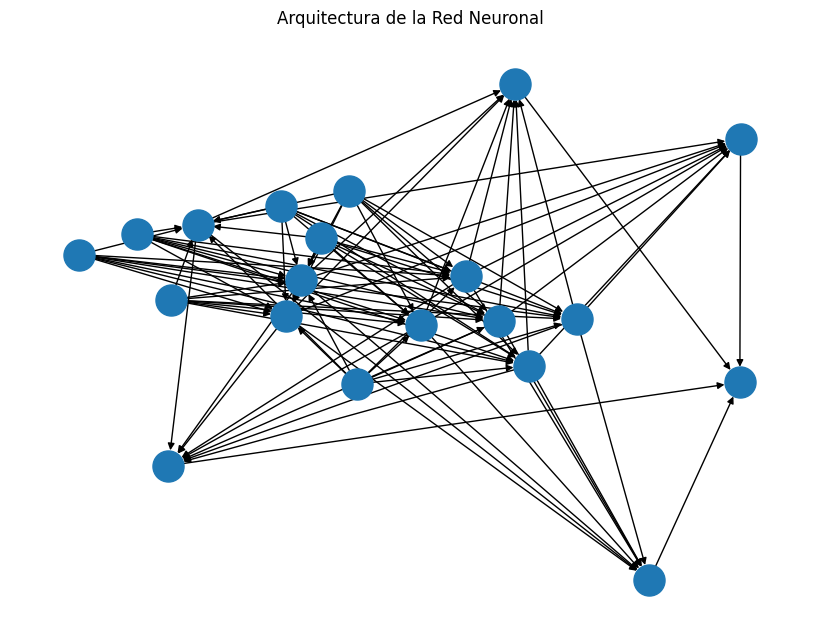

In [ ]:
import networkx as nx

G = nx.DiGraph()

layers = [7,8,4,1]

for i in range(len(layers)-1):
    for j in range(layers[i]):
        for k in range(layers[i+1]):
            G.add_edge(f"L{i}N{j}", f"L{i+1}N{k}")

plt.figure(figsize=(8,6))
nx.draw(G, node_size=500, with_labels=False)
plt.title("Arquitectura de la Red Neuronal")
plt.show()

### 10. Conclusiones

A partir del análisis exploratorio se observó que variables como
sweetness, juiciness y ripeness tienen mayor relación con la calidad
de la manzana, mientras que la acidez puede ser un factor importante, este no refleja un mayor cambio en que tan buena es la manzana.

Se implementó una red neuronal desde cero utilizando el algoritmo
de aprendizaje backpropagation.

La red neuronal obtuvo un accuracy superior al 80%, lo cual demuestra
que las características del dataset permiten predecir correctamente
la calidad de las manzanas.

H1 = 0.64
H2 = 0.69
error = 0.0084